In [317]:
# This code creates a (k, lambda, eta, beta)- base synopsis generator that is (epsilon,delta)-DP 



import numpy as np
import math
import sympy as sp
from itertools import combinations
import pandas as pd
import time
import copy


lower_bound = -1 # data lower bound
upper_bound = 1  # data upper bound

ub_on_p = 20

########## NEED TO VERIFY DATA PRECISION so that we could set the correct m if we wanted to use boosting ##############
data_precision = 4 # data precision of X


n = 100
num_points = 2*n # number of data points
m = num_points*math.ceil(math.log2(((upper_bound - lower_bound)/10**(-data_precision)) +1)) # size of the domain universe

epsilon = 15
delta =  1e-1 # DP parameter
eta = 0.001 # edge for boosting
beta = 0.05 # failure probability of the base synopsis

############## This line needs to be changed to k = # queries needed for generalization #####################
# k = math.ceil(2*((math.log(2/beta)+m)/(1-2*eta))) # number of query sample as demanded by Lemma 6.5 
k = 50
#######################################################################################################

# consider the lp_norms query:
# q_i(X) = 1/n * \|X\|_i, where 1<= i <= 20, with 0.0001 precision
rho = (upper_bound-lower_bound)/num_points # l_1 sensitivity 




# Llambda = 0.01 # parameter lambda, the amount of query output error tolerated 
# epsilon = (math.log(2*k/beta)*4*rho*math.sqrt(2*k*math.log(1/delta)))/Llambda
# epsilon = round(epsilon,2)+10**(-data_precision) # round epsilon up to 2 decimal points 

Llambda = (math.log(2*k/beta)*4*rho*math.sqrt(2*k*math.log(1/delta)))/epsilon
Llambda = round(Llambda,2)+10**(-data_precision) # round epsilon up to 2 decimal points 

# to study just one query, set k=1
# k = 2

tau = 0.001 # total loss stopping criterion



In [318]:
import random 
# decide on a set of real data 
real_X = np.random.choice(np.arange(lower_bound, upper_bound+0.01, 0.01), num_points, replace=False)
# sum_real_X_squared = np.sum(np.square(real_X))

# initialize the synopsis to be some arbirary set of data, say from the standard normal
# for verification purposes, if fake_X = real_X, the initial error should be the same as the added laplace noise
# fake_X = real_X 
fake_X = np.random.randn(num_points)
# fake_X = np.ones(num_points)*(-0.9)


# fake_X_normalizer = np.max(np.abs(fake_X))
# for idx, i in enumerate(fake_X):
#     if np.abs(i)>=1 :
#         fake_X[idx] = i/fake_X_normalizer
# # fake_X = np.random.uniform(low=lower_bound, high=upper_bound, size=num_points)

fake_X_copy = copy.copy(fake_X) # save a copy of fake_X
fake_X_original = copy.copy(fake_X)
# sum_fake_X_squared = np.sum(np.square(fake_X_copy))


# for lp norms, each coeff is a p value. we set 1<p<1000, with 2 decimal points precision
all_coeff = np.round(np.linspace(1,ub_on_p,num=10000),data_precision)
# sampled_queries = np.array(random.sample(list(all_coeff),k))
sampled_queries = np.random.choice(all_coeff, size=k, replace=False)

In [319]:
# np.random.laplace(loc=0.0, scale=rho*(2*math.sqrt(2*k*math.log(1/delta))/epsilon), size=2).reshape(-1,1)
all_coeff


array([ 1.    ,  1.0019,  1.0038, ..., 19.9962, 19.9981, 20.    ])

In [320]:
# fake_X = copy.copy(fake_X_original)



#### BOOSTING LOOP STARTS ####

# initialize all-zero arrays to store noiselss query output, noisy output, and laplace noise  
real_output = np.zeros(k)
real_data_noisy_output = np.zeros(k)
lap_noise = np.zeros(k)
fake_output = np.zeros(k)
error = np.zeros(k) # store |q(X) - noisy_output| for each q



# # for each query, compute its real output, noisy output, and initial error
for index, item in enumerate(sampled_queries):
    sum_real_xi_p = np.sum(np.abs(real_X)**item)
    real_output[index] = sum_real_xi_p**(1/item)/num_points
    lap_noise[index] = np.random.laplace(loc=0.0, scale=rho*(2*math.sqrt(2*k*math.log(1/delta))/epsilon), size=1).reshape(-1,1)
    real_data_noisy_output[index] = real_output[index] + lap_noise[index]

    # compute query output on fake data 
    sum_fake_xi_p = np.sum(np.abs(fake_X)**item)
    fake_output[index] = sum_fake_xi_p**(1/item)/num_points

    # calculate initial error
    error[index] = abs(fake_output[index]-real_data_noisy_output[index])

# save a copy of lap_noise
lap_noise_copy = copy.copy(lap_noise) 



# for index, item in enumerate(sampled_queries):
    
#     # real output 
#     real_output[index] = item*sum_real_X_squared/num_points # quadratic query
#     # real_output[index] = item*np.sum(real_X)/num_points # linear query

    
#     # # compute noisy output on the real data
#     # k_actual = math.ceil(2*((math.log(2/beta)+m)/(1-2*eta))) # number of query sample as demanded by Lemma 6.5 
#     # lap_noise[index] = np.random.laplace(loc=0.0, scale=rho*(2*math.sqrt(2*k*math.log(1/delta))/epsilon), size=None) 
#     # artificially tune the lap noise down by a half
#     lap_noise[index] = np.random.laplace(loc=0.0, scale=rho*(2*math.sqrt(2*k*math.log(1/delta))/epsilon), size=None)
#     # lap_noise[index] = 0


#     real_data_noisy_output[index] = real_output[index] + lap_noise[index]

#     # # compute query output on fake data 
#     fake_output[index] = item*sum_fake_X_squared/num_points # quadratic query
#     # fake_output[index] = item*np.sum(fake_X)/num_points # linear query

#     # # calculate initial error
#     # # notice that this is |q(X) - real_data_noisy_output|
#     error[index] = abs(fake_output[index]-real_data_noisy_output[index])



/tmp/ipykernel_276164/1863270159.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lap_noise[index] = np.random.laplace(loc=0.0, scale=rho*(2*math.sqrt(2*k*math.log(1/delta))/epsilon), size=1).reshape(-1,1)


In [321]:
print("# lap noise above lambda/2 = ",sum(abs(lap_noise)>=Llambda/2) )

# calculate total loss on real_X
total_loss_plus = np.sum(np.exp((real_output-real_data_noisy_output)/Llambda-1))
total_loss_minus = np.sum(np.exp((real_data_noisy_output-real_output)/Llambda-1))
total_loss = total_loss_plus + total_loss_minus 
total_loss_real_X = copy.copy(total_loss)
print("Total loss of real_output: ", total_loss_real_X)
print("# queries = k=", k)
print("# queries above lambda/2 error = ",sum(error>Llambda/2))
print("epsilon = ", epsilon)
print("Llambda = ", Llambda)

# lap noise above lambda/2 =  0
Total loss of real_output:  36.94861737955018
# queries = k= 50
# queries above lambda/2 error =  2
epsilon =  15
Llambda =  0.3101


In [322]:
## NON-STOCHASTIC 
#### COORDINATE DESCENT LOOP STARTS HERE ###
#### In this loop, we do coordinate descent, NOT multivariate Newton's method ####

# initialize number of coordinate descent iterations = 0
num_iter_descent = 0

x_coord_changed = np.full(num_points, False, dtype=bool)
x_coord_changed = {i: x_coord_changed[i] for i in range(len(x_coord_changed))}


# while we don't have |q(X) - noisy_output|<lambda/2 for all q, continue coordinate descent 
# while not np.all(error < Llambda/2) and sum(error>Llambda/2)>sum(abs(lap_noise)>=Llambda/2) :
while (num_iter_descent == 0 or  total_loss_update > tau) :
    
    # calculate the current total loss, which is a two-sided loss for each query function
    total_loss_plus = np.sum(np.exp((fake_output-real_data_noisy_output)/Llambda-1))
    total_loss_minus = np.sum(np.exp((real_data_noisy_output-fake_output)/Llambda-1))
    total_loss = total_loss_plus + total_loss_minus 

    ### compute the partial derivative of the loss function with respect to each coordinate 
    loss_gradient = np.zeros(num_points) # initialize the partial derivative of each coordinate to be zero
    
    # fix xi    
    for i in range(num_points):
        xi = fake_X[i]

        # calculate the dq_j/dx_i for all j = 1, ..., k
        # query_grad_wrt_xi_array = sampled_queries[:,i].reshape(-1,1)/num_points
        query_grad_wrt_xi_array = np.sign(xi)*(np.abs(xi)/sum_fake_xi_p**(1/sampled_queries))**(sampled_queries-1)/num_points


        loss_gradient_plus = np.sum(query_grad_wrt_xi_array*np.exp((fake_output-real_data_noisy_output)/Llambda - 1)/Llambda)
        loss_gradient_minus = np.sum(-query_grad_wrt_xi_array*np.exp(-(fake_output-real_data_noisy_output)/Llambda - 1)/Llambda)
        loss_gradient[i] = loss_gradient_plus + loss_gradient_minus

    # create a dictionary for loss_gradient
    loss_gradient_dict = {i: loss_gradient[i] for i in range(len(loss_gradient))}


    # find the coordinate with the max absolute value part_derivative 
    filtered_loss_grad_dict = {k: v for k, v in loss_gradient_dict.items() if not x_coord_changed[k]}
    x_coord_descent = max(filtered_loss_grad_dict, key=lambda k: abs(filtered_loss_grad_dict[k]))

    
        

    # update x value at the coordinate x_coord_descent
    # First, we calculate the 2nd derivative wrt x_coord_descent
    xi = fake_X[x_coord_descent] 
    
    query_grad_wrt_x_coord_descent_array = np.sign(xi)*(np.abs(xi)/sum_fake_xi_p**(1/sampled_queries))**(sampled_queries-1)/num_points
    query_hessian_wrt_x_coord_descent_array = ((1/sampled_queries-1)*sampled_queries*sum_fake_xi_p**(1/sampled_queries-2)*xi**2*np.abs(xi)**(2*sampled_queries-4)+sum_fake_xi_p**(1/sampled_queries-1)*(np.abs(xi)**(sampled_queries-2)*xi**2*np.abs(xi)**(sampled_queries-4)))/num_points

    loss_hessian_wrt_chosen_xi_plus = np.sum((np.exp((fake_output-real_data_noisy_output)/Llambda-1)*(query_hessian_wrt_x_coord_descent_array+query_grad_wrt_x_coord_descent_array**2/Llambda))/Llambda)
    loss_hessian_wrt_chosen_xi_minus = np.sum(-(np.exp(-(fake_output-real_data_noisy_output)/Llambda-1)*(query_hessian_wrt_x_coord_descent_array-query_grad_wrt_x_coord_descent_array**2/Llambda))/Llambda)
    loss_hessian_wrt_chosen_x_coord = loss_hessian_wrt_chosen_xi_plus + loss_hessian_wrt_chosen_xi_minus
    # loss_hessian_wrt_chosen_x_coord = sampled_queries/num_points # linear queries

    
    ### Backtracking Line Search Sub-routine ###
    # Backtracking line search 
    # initialize a step size, constants alpha1 and alpha2
    t = 1
    alpha1 = 0.05 # usually 0 < alpha1 < 0.5
    alpha2 = 0.5 # usually 0 < alpha2 < 1

    # initialize AG_condition = 0
    AG_condition = 0

    # make a copy of the curent fake_X
    fake_X_copy_linesearch = copy.copy(fake_X)

    while AG_condition == 0: 

        # calculate f(x+t*Delta x)
        fake_X_copy_linesearch[x_coord_descent] = xi - t*loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord

        # update fake_output
        fake_output_linesearch = np.zeros(k)
        for index, item in enumerate(sampled_queries): 
            sum_fake_xi_p_linesearch = np.sum(np.abs(fake_X_copy_linesearch)**item)
            fake_output_linesearch[index] = sum_fake_xi_p_linesearch**(1/item)/num_points
            
        
        
        # fake_output_linesearch = sampled_queries*np.sum(fake_X_copy_linesearch) /num_points
        # loss_current_stepsize = np.sum(np.square(fake_output_linesearch-real_data_noisy_output))/Llambda
        loss_current_stepsize_plus = np.sum(np.exp((fake_output_linesearch-real_data_noisy_output)/Llambda-1))
        loss_current_stepsize_minus = np.sum(np.exp((real_data_noisy_output-fake_output_linesearch)/Llambda-1))
        loss_current_stepsize = loss_current_stepsize_plus + loss_current_stepsize_minus 

        # print('loss_current', loss_current_stepsize)

        # calculate f(x)+alpha1*t*grad_f*Delta x
        loss_damped_stepsize = total_loss + alpha1*t*loss_gradient[x_coord_descent]*(- loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord)
        # print('loss_dampened', loss_damped_stepsize)
        
        # if loss_current_stepsize > loss_damped_stepsize or -1>xi - t*loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord or xi - t*loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord>1:
        if loss_current_stepsize > loss_damped_stepsize:
            t = t* alpha2
            
            
            # print("t = ", t)

        else: 
            AG_condition = 1 
            print("t = ", t)
    ############



    # update fake_X at coordinate = x_coord_descent using 2nd order Newton's method 
    xi_update = - t*loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord
    fake_X[x_coord_descent] = xi + xi_update

    # if fake_X[x_coord_descent] <= 3*lower_bound or fake_X[x_coord_descent] >= 3*upper_bound:
    #     x_coord_changed[x_coord_descent] = True 
        
    # if xi+xi_update <= 1 and xi+xi_update >= -1:
    #     fake_X[x_coord_descent] = xi + xi_update
    # # if the proposed update will overshoot, we skip this coordinate 
    # else:
    #     x_coord_changed[x_coord_descent] = True
    

    # update fake_output
    for index, item in enumerate(sampled_queries): 
        sum_fake_xi_p = np.sum(np.abs(fake_X)**item)
        fake_output[index] = sum_fake_xi_p**(1/item)/num_points

    # update error
    error = abs(fake_output-real_data_noisy_output)

    # update total loss
    total_loss_plus = np.sum(np.exp((fake_output-real_data_noisy_output)/Llambda-1))
    total_loss_minus = np.sum(np.exp((real_data_noisy_output-fake_output)/Llambda-1))
    total_loss_after = total_loss_plus + total_loss_minus 

    total_loss_update = total_loss-total_loss_after 

    # print current progress
    print(f"#iter {num_iter_descent} x_co={x_coord_descent}, 1st={loss_gradient[x_coord_descent]:e}, 2nd={loss_hessian_wrt_chosen_x_coord:e}, # queries above err={sum(error>Llambda/2)}, xi={xi} fake x={fake_X[x_coord_descent]}")
    print(f"Total loss = {total_loss:e}; Total_loss - Total_loss_real_X = {total_loss-total_loss_real_X:e}; Total_loss_update = {total_loss_update:e}")
    
    num_iter_descent += 1 




t =  9.5367431640625e-07
#iter 0 x_co=174, 1st=-1.227606e+02, 2nd=3.365252e+11, # queries above err=2, xi=-3.6137415435961064 fake x=-3.613741543596106
Total loss = 3.750800e+01; Total_loss - Total_loss_real_X = 5.593838e-01; Total_loss_update = 0.000000e+00


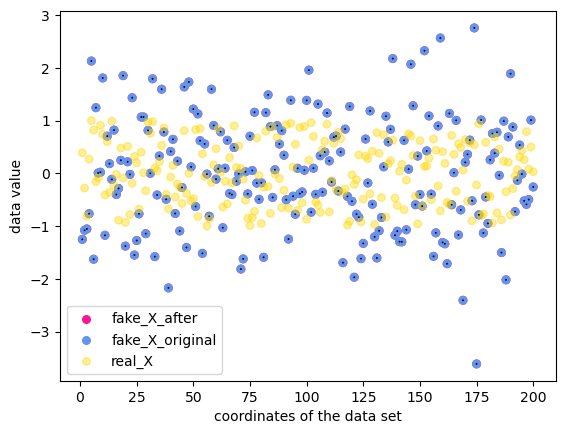

<Figure size 800x4000 with 0 Axes>

In [323]:
import matplotlib.pyplot as plt


## plot distribution of fake_X and real_X
# plt.hist(fake_X, bins=100, density=True, alpha=0.6, color='blue', label='fake_X_after')
# plt.hist(fake_X_original, bins=100, density=True, alpha=0.6, color='green', label='fake_X_original')
# plt.hist(real_X, bins=100, density=True, alpha=0.6, color='red',label='real_X')

# plot fake_X, real_X, and fake_X_after
# initialize the x-axis to be # data points
x_axis = np.arange(start=1, stop=num_points+1, step=1) 
plt.scatter(x_axis, fake_X, s = np.full(len(fake_X),30),label="fake_X_after", color='deeppink')
plt.scatter(x_axis, fake_X_original, s = np.full(len(fake_X),30),label="fake_X_original", color='cornflowerblue')
plt.scatter(x_axis, real_X, s = np.full(len(fake_X),30),label="real_X",color='gold', alpha=0.4)

# plot the difference between fake_X_original and fake_X_after

plt.quiver(x_axis, fake_X_original, x_axis-x_axis, fake_X - fake_X_original, angles='xy', scale_units='xy', scale=1, color='black', alpha=1)

 

plt.legend()


plt.xlabel('coordinates of the data set')
plt.ylabel('data value')
# plt.grid(True)

# plt.grid(True)
plt.figure(figsize=(8, 40), dpi= 100)
plt.show()




In [ ]:
# ### stochastic gradient descent 
# #### COORDINATE DESCENT LOOP STARTS HERE ###
# #### In this loop, we do coordinate descent, NOT multivariate Newton's method ####

# # initialize number of coordinate descent iterations = 0
# num_iter_descent = 0

# x_coord_changed = np.full(num_points, False, dtype=bool)
# x_coord_changed = {i: x_coord_changed[i] for i in range(len(x_coord_changed))}


# # while we don't have |q(X) - noisy_output|<lambda/2 for all q, continue coordinate descent 
# while not np.all(error < Llambda/2):
    
#     # calculate the current total loss, which includes two copies of loss for each query function
#     total_loss_plus = np.sum(np.exp((fake_output-real_data_noisy_output)/Llambda-1))
#     total_loss_minus = np.sum(np.exp((real_data_noisy_output-fake_output)/Llambda-1))
#     total_loss = total_loss_plus + total_loss_minus 

#     ### compute the partial derivative of the loss function with respect to each coordinate 
#     query_loss_gradient = np.zeros(num_points) # initialize the partial derivative of the current query wrt each coordinate to be zero

#     # go thru all queries one by one, starting with q_0 all the way to q_{k-1}
#     current_q = 0

#     while current_q < k:
#         num_iter_q = 0 
#         x_coord_changed = np.full(num_points, False, dtype=bool)
#         x_coord_changed = {i: x_coord_changed[i] for i in range(len(x_coord_changed))}

#         sampled_queries_q = sampled_queries[current_q]
#         fake_output_q = fake_output[current_q]
#         real_data_noisy_output_q = real_data_noisy_output[current_q]

#         # we want to gradient descent on one query until it satisfies the error bound
#         while not error[current_q] < Llambda/2:

#             query_loss_plus = np.exp((fake_output_q-real_data_noisy_output_q)/Llambda-1)
#             query_loss_minus = np.exp((real_data_noisy_output_q-fake_output_q)/Llambda-1)
#             query_loss = query_loss_plus + query_loss_minus

#             for i in range(num_points):
#                 # fix xi    
#                 xi = fake_X[i]

#                 # calculate the dq_j/dx_i for all j = 1, ..., k
#                 # query_grad_wrt_xi_array = 2*xi*sampled_queries_q/num_points
#                 loss_gradient_plus = np.sum(2*sampled_queries_q*xi*np.exp((fake_output_q-real_data_noisy_output_q)/Llambda - 1)/(Llambda*num_points))
#                 loss_gradient_minus = np.sum(-2*sampled_queries_q*xi*np.exp(-(fake_output_q-real_data_noisy_output_q)/Llambda - 1)/(Llambda*num_points))
#                 query_loss_gradient[i] = loss_gradient_plus + loss_gradient_minus

#             # create a dictionary for query_loss_gradient
#             loss_gradient_dict = {i: query_loss_gradient[i] for i in range(len(query_loss_gradient))}


#             # find the coordinate with the max absolute value part_derivative 
#             filtered_loss_grad_dict = {k: v for k, v in loss_gradient_dict.items() if not x_coord_changed[k]}
#             x_coord_descent = max(filtered_loss_grad_dict, key=lambda k: abs(filtered_loss_grad_dict[k]))

        
            

#             # update x value at the coordinate x_coord_descent
#             # First, we calculate the 2nd derivative wrt x_coord_descent
#             xi = fake_X[x_coord_descent] 
#             # quadratic query

#             loss_hessian_wrt_chosen_xi_plus = (2*sampled_queries_q)/(Llambda*num_points)*np.exp((fake_output_q-real_data_noisy_output_q)/Llambda -1)*(1+2*sampled_queries_q*xi**2/(Llambda*num_points))
#             loss_hessian_wrt_chosen_xi_minus = -(2*sampled_queries_q)/(Llambda*num_points)*np.exp(-(fake_output_q-real_data_noisy_output_q)/Llambda -1)*(1-2*sampled_queries_q*xi**2/(Llambda*num_points))
#             loss_hessian_wrt_chosen_x_coord = loss_hessian_wrt_chosen_xi_plus + loss_hessian_wrt_chosen_xi_minus
#             # loss_hessian_wrt_chosen_x_coord = sampled_queries_q/num_points # linear queries

            
#             ### Backtracking Line Search Sub-routine ###
#             # Backtracking line search 
#             # initialize a step size, constants alpha1 and alpha2
#             t = 1
#             alpha1 = 0.2 # usually 0 < alpha1 < 0.5
#             alpha2 = 0.5 # usually 0 < alpha2 < 1

#             # initialize AG_condition = 0
#             AG_condition = 0

#             # make a copy of the curent fake_X
#             fake_X_copy_linesearch = copy.copy(fake_X)

#             while AG_condition == 0: 

#                 # calculate f(x+t*Delta x)
#                 fake_X_copy_linesearch[x_coord_descent] = xi - t*query_loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord
#                 # update fake_output_q 
#                 sum_fake_X_squared_linesearch = np.sum(np.square(fake_X_copy_linesearch))
#                 fake_output_q_linesearch = sampled_queries_q*sum_fake_X_squared_linesearch /num_points
#                 # fake_output_q_linesearch = sampled_queries_q*np.sum(fake_X_copy_linesearch) /num_points
#                 # loss_current_stepsize = np.sum(np.square(fake_output_q_linesearch-real_data_noisy_output_q))/Llambda
#                 loss_current_stepsize_plus = np.exp((fake_output_q_linesearch-real_data_noisy_output_q)/Llambda-1)
#                 loss_current_stepsize_minus = np.exp((real_data_noisy_output_q-fake_output_q_linesearch)/Llambda-1)
#                 loss_current_stepsize = loss_current_stepsize_plus + loss_current_stepsize_minus 

#                 print('loss_current', loss_current_stepsize)

#                 # calculate f(x)+alpha1*t*grad_f*Delta x
#                 loss_damped_stepsize = query_loss + alpha1*t*query_loss_gradient[x_coord_descent]*(- query_loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord)
#                 print('loss_dampened', loss_damped_stepsize)
                
#                 # if loss_current_stepsize > loss_damped_stepsize or -1>xi - t*query_loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord or xi - t*query_loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord>1:
#                 if loss_current_stepsize > loss_damped_stepsize:
#                     t = t* alpha2
                    
                    
#                     print("t = ", t)

#                 else: 
#                     AG_condition = 1 
#                     print("t = ", t)
#             ############



#             # update fake_X at coordinate = x_coord_descent using 2nd order Newton's method 
#             xi_update = - t*query_loss_gradient[x_coord_descent]/loss_hessian_wrt_chosen_x_coord
#             fake_X[x_coord_descent] = xi + xi_update

#             if fake_X[x_coord_descent] <= -1 or fake_X[x_coord_descent] >= 1:
#                 x_coord_changed[x_coord_descent] = True 
                
#             # if xi+xi_update <= 1 and xi+xi_update >= -1:
#             #     fake_X[x_coord_descent] = xi + xi_update
#             # # if the proposed update will overshoot, we skip this coordinate 
#             # else:
#             #     x_coord_changed[x_coord_descent] = True
            

#             # update fake_output
#             sum_fake_X_squared = np.sum(np.square(fake_X))
#             fake_output = sampled_queries*sum_fake_X_squared /num_points # quadratic query 
#             # fake_output_q = sampled_queries_q*np.sum(fake_X)/num_points # linear query


#             # update error
#             error = abs(fake_output-real_data_noisy_output)

#             # update total loss
#             total_loss_plus = np.sum(np.exp((fake_output-real_data_noisy_output)/Llambda-1))
#             total_loss_minus = np.sum(np.exp((real_data_noisy_output-fake_output)/Llambda-1))
#             total_loss = total_loss_plus + total_loss_minus 

#             # update query loss
#             query_loss_plus = np.exp((fake_output_q-real_data_noisy_output_q)/Llambda-1)
#             query_loss_minus = np.exp((real_data_noisy_output_q-fake_output_q)/Llambda-1)
#             query_loss = query_loss_plus + query_loss_minus

#             num_iter_q = num_iter_q + 1 
#             print(f"current_q={current_q},#iter_q={num_iter_q}, x_co={x_coord_descent}, query_loss={query_loss}, total_loss={total_loss}")

#         current_q = current_q + 1 
#     # print current progress
#     # print(f"#iter {num_iter_descent} x_co={x_coord_descent}, 1st={query_loss_gradient[x_coord_descent]}, 2nd={loss_hessian_wrt_chosen_x_coord}, # queries above err={sum(error>Llambda/2)}, xi={xi} fake x={fake_X[x_coord_descent]}")
#     # print('Total loss = ', total_loss)
    
#     num_iter_descent += 1 


